<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T3/semana-01/blob/main/Exemplo_Visao_Computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 01

In [ ]:
# CÉLULA 1: Importação de Bibliotecas
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

print("Bibliotecas importadas com sucesso! Nossa caixa de ferramentas está pronta.")

# ---


In [ ]:

# CÉLULA 2: Como o computador enxerga uma imagem?
print("Baixando imagem de exemplo...")
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "imagem_teste.jpg")

# Carregando a imagem
imagem = cv2.imread("imagem_teste.jpg")
# O OpenCV lê em BGR, precisamos converter para RGB para mostrar corretamente na tela
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Exibindo a imagem para os alunos
plt.figure(figsize=(5,5))
plt.imshow(imagem_rgb)
plt.title("O que o Ser Humano enxerga")
plt.axis('off')
plt.show()

# ---


In [ ]:
# CÉLULA 3: O Segredo da Visão Computacional (A Matriz)
print("\nO que o Computador enxerga (Matriz de Pixels):")
print(f"Formato da imagem: {imagem.shape} -> (Altura, Largura, Canais de Cor RGB)")
print("\nVeja um pedacinho da imagem em números (uma grade de 3x3 pixels no canto da foto):")
print(imagem[0:3, 0:3])

# ---


In [ ]:
# CÉLULA 4: Pré-processamento (Preparando os Dados)
# Algoritmos de detecção costumam ser mais eficientes em Preto e Branco (escala de cinza)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(imagem_cinza, cmap='gray')
plt.title("Imagem em Escala de Cinza (Apenas 1 canal de cor)")
plt.axis('off')
plt.show()

print(f"\nNovo formato da imagem: {imagem_cinza.shape} -> Note que o '3' dos canais de cor sumiu!")

# ---

In [ ]:
# CÉLULA 5: A Inteligência Artificial em Ação (Detecção)
# Carregando um modelo clássico pré-treinado do OpenCV capaz de achar padrões de rostos
modelo_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# A IA varre a matriz de números procurando o padrão matemático de um rosto
rostos = modelo_cascade.detectMultiScale(imagem_cinza, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

print(f"IA processando... Encontrado(s) {len(rostos)} rosto(s)!")

# ---

In [ ]:

# CÉLULA 6: Desenhando o resultado e exibindo
imagem_resultado = imagem_rgb.copy()

# Para cada rosto encontrado, desenhamos um retângulo verde
for (x, y, largura, altura) in rostos:
    # (Imagem, ponto_inicial, ponto_final, cor(R,G,B), espessura)
    cv2.rectangle(imagem_resultado, (x, y), (x + largura, y + altura), (0, 255, 0), 3)

plt.figure(figsize=(7,7))
plt.imshow(imagem_resultado)
plt.title("Resultado do Machine Learning")
plt.axis('off')
plt.show()

# Ex 02

In [ ]:
# CÉLULA 7: Trabalhando com Mais de 3 Canais de Cor (Imagens Multiespectrais)
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

print("--- 🛰️ PIPELINE DE IMAGENS DE SATÉLITE DE 4 CANAIS ---")

# 1. Baixando uma imagem real de satélite no formato TIF (que suporta múltiplos canais)
print("Baixando imagem de satélite com dados de Infravermelho...")
url_satelite = "https://raw.githubusercontent.com/OSGeo/gdal/master/autotest/gcore/data/byte.tif" # URL Atualizada
urllib.request.urlretrieve(url_satelite, "imagem_satelite.tif")

# 2. Carregando a imagem mantendo TODOS os seus canais originais intactos
# O parâmetro cv2.IMREAD_UNCHANGED garante que o OpenCV não descarte o 4º canal
imagem_sat = cv2.imread("imagem_satelite.tif", cv2.IMREAD_UNCHANGED)

# Ajuste para garantir que a imagem tenha 4 canais, mesmo se a original for 1-canal
if imagem_sat.ndim == 2: # Se for uma imagem em escala de cinza (Altura, Largura)
    # Adiciona uma dimensão de canal (H, W, 1)
    imagem_sat = np.expand_dims(imagem_sat, axis=-1)
    # Replica o canal único para criar 4 canais idênticos (H, W, 4)
    imagem_sat = np.concatenate([imagem_sat, imagem_sat, imagem_sat, imagem_sat], axis=-1)
elif imagem_sat.ndim == 3 and imagem_sat.shape[-1] < 4: # Se for (Altura, Largura, Canais) onde Canais < 4
    # Preenche com zeros ou replica canais existentes para alcançar 4 canais
    # Para simplificar, vamos replicar o último canal ou preencher com zeros se tiver menos de 3 canais.
    # Uma solução mais robusta pode envolver atribuições de canais específicos.
    while imagem_sat.shape[-1] < 4:
        imagem_sat = np.concatenate([imagem_sat, imagem_sat[:, :, -1:]], axis=-1) # Replica o último canal

print(f"\n📊 Formato original da imagem: {imagem_sat.shape}")
print("Significado do Shape: (Altura, Largura, 4 Canais de Cor: Azul, Verde, Vermelho e Infravermelho Próximo)")

# 3. Pré-processamento e Transformação (Igual você fez com a escala de cinza)
# Vamos redimensionar para 28x28 para alimentar a nossa rede neural de teste de forma leve
imagem_ajustada = cv2.resize(imagem_sat, (28, 28))
# Normalizando os pixels (escala float de 0.0 a 1.0) para a IA processar melhor
imagem_final = imagem_ajustada / 255.0

print(f"Novo formato após a transformação para a IA: {imagem_final.shape}")

--- 🛰️ PIPELINE DE IMAGENS DE SATÉLITE DE 4 CANAIS ---
Baixando imagem de satélite com dados de Infravermelho...

📊 Formato original da imagem: (20, 20, 4)
Significado do Shape: (Altura, Largura, 4 Canais de Cor: Azul, Verde, Vermelho e Infravermelho Próximo)
Novo formato após a transformação para a IA: (28, 28, 4)


In [ ]:
# 5. Criando a estrutura da IA preparada para receber 4 canais
# Note o 'input_shape=(28, 28, 4)' casando perfeitamente com o dado transformado
IA_satelite = models.Sequential([
    layers.Input(shape=(28, 28, 4)), # Usando a camada Input conforme recomendado
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(2, activation='softmax') # 0 = Floresta | 1 = Cidade
])

IA_satelite.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n🤖 IA criada e configurada com sucesso para receber matrizes de 4 dimensões de cor!")


🤖 IA criada e configurada com sucesso para receber matrizes de 4 dimensões de cor!


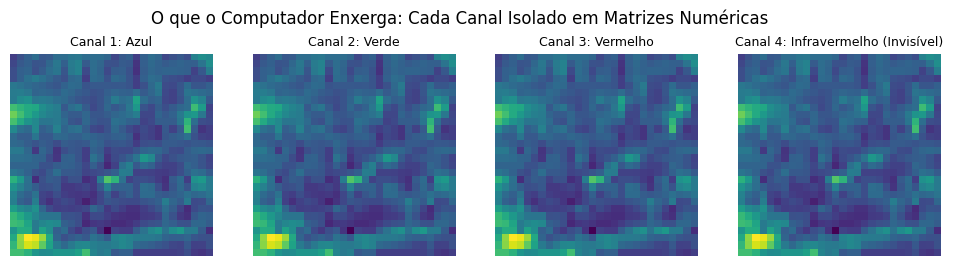

In [ ]:
# 4. Demonstração Visual dos Canais para os Alunos
fig, eixos = plt.subplots(1, 4, figsize=(12, 3))
nomes_canais = ['Canal 1: Azul', 'Canal 2: Verde', 'Canal 3: Vermelho', 'Canal 4: Infravermelho (Invisível)']

for i in range(4):
    eixos[i].imshow(imagem_final[:, :, i], cmap='viridis')
    eixos[i].set_title(nomes_canais[i], fontsize=9)
    eixos[i].axis('off')
plt.suptitle("O que o Computador Enxerga: Cada Canal Isolado em Matrizes Numéricas")
plt.show()